In [4]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
Note: you may need to restart the kernel to use updated packages.


# US Consulate Sensor 2018 - 2022

In [1]:
import pandas as pd

input_file = "data/hcmc_lstm_ready_weather.csv"  
df = pd.read_csv(input_file)
df.head()

,datetime,value,lag_1h,lag_2h,lag_3h,lag_24h,lag_168h,roll_mean_24h,roll_std_24h,hour_sin,...,wind_direction,precipitation,temp_lag_1h,temp_lag_24h,humid_lag_1h,humid_lag_24h,wind_lag_1h,wind_lag_24h,temp_humid_interaction,wind_precip_interaction
0,2018-01-08 03:00:00,18.0,20.0,23.0,21.0,16.0,24.000000,18.875000,10.178035,0.707107,...,126.0,0.0,24.8,24.5,90.0,92.0,9.1,8.3,22.386,0.85
1,2018-01-08 04:00:00,17.0,18.0,20.0,23.0,14.0,29.666667,19.000000,10.133886,0.866025,...,122.0,0.0,24.6,24.4,91.0,93.0,8.5,7.1,22.448,0.81
2,2018-01-08 09:00:00,14.0,12.0,14.0,16.0,10.0,38.000000,17.645833,6.568170,0.707107,...,99.0,0.0,26.5,28.1,78.0,71.0,8.8,10.9,19.596,1.09
3,2018-01-08 10:00:00,17.0,14.0,12.0,14.0,10.0,43.000000,17.937500,6.366202,0.500000,...,93.0,0.1,28.4,29.5,69.0,64.0,10.9,10.8,18.724,3.02
4,2018-01-08 11:00:00,19.0,17.0,14.0,12.0,17.0,46.000000,18.020833,6.366487,0.258819,...,99.0,0.1,30.2,30.9,62.0,59.0,15.1,10.7,17.898,2.62


In [2]:
df.isnull().sum()

datetime                   0
value                      0
lag_1h                     0
lag_2h                     0
lag_3h                     0
lag_24h                    0
lag_168h                   0
roll_mean_24h              0
roll_std_24h               0
hour_sin                   0
hour_cos                   0
day_sin                    0
day_cos                    0
month_sin                  0
month_cos                  0
temperature                0
humidity                   0
wind_speed                 0
wind_direction             0
precipitation              0
temp_lag_1h                0
temp_lag_24h               0
humid_lag_1h               0
humid_lag_24h              0
wind_lag_1h                0
wind_lag_24h               0
temp_humid_interaction     0
wind_precip_interaction    0
dtype: int64

In [3]:
df.isna().sum()

datetime                   0
value                      0
lag_1h                     0
lag_2h                     0
lag_3h                     0
lag_24h                    0
lag_168h                   0
roll_mean_24h              0
roll_std_24h               0
hour_sin                   0
hour_cos                   0
day_sin                    0
day_cos                    0
month_sin                  0
month_cos                  0
temperature                0
humidity                   0
wind_speed                 0
wind_direction             0
precipitation              0
temp_lag_1h                0
temp_lag_24h               0
humid_lag_1h               0
humid_lag_24h              0
wind_lag_1h                0
wind_lag_24h               0
temp_humid_interaction     0
wind_precip_interaction    0
dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34138 entries, 0 to 34137
Data columns (total 28 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   datetime                 34138 non-null  object 
 1   value                    34138 non-null  float64
 2   lag_1h                   34138 non-null  float64
 3   lag_2h                   34138 non-null  float64
 4   lag_3h                   34138 non-null  float64
 5   lag_24h                  34138 non-null  float64
 6   lag_168h                 34138 non-null  float64
 7   roll_mean_24h            34138 non-null  float64
 8   roll_std_24h             34138 non-null  float64
 9   hour_sin                 34138 non-null  float64
 10  hour_cos                 34138 non-null  float64
 11  day_sin                  34138 non-null  float64
 12  day_cos                  34138 non-null  float64
 13  month_sin                34138 non-null  float64
 14  month_cos             

C:\Users\Admin\AppData\Local\Temp\ipykernel_24948\640532788.py:29: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


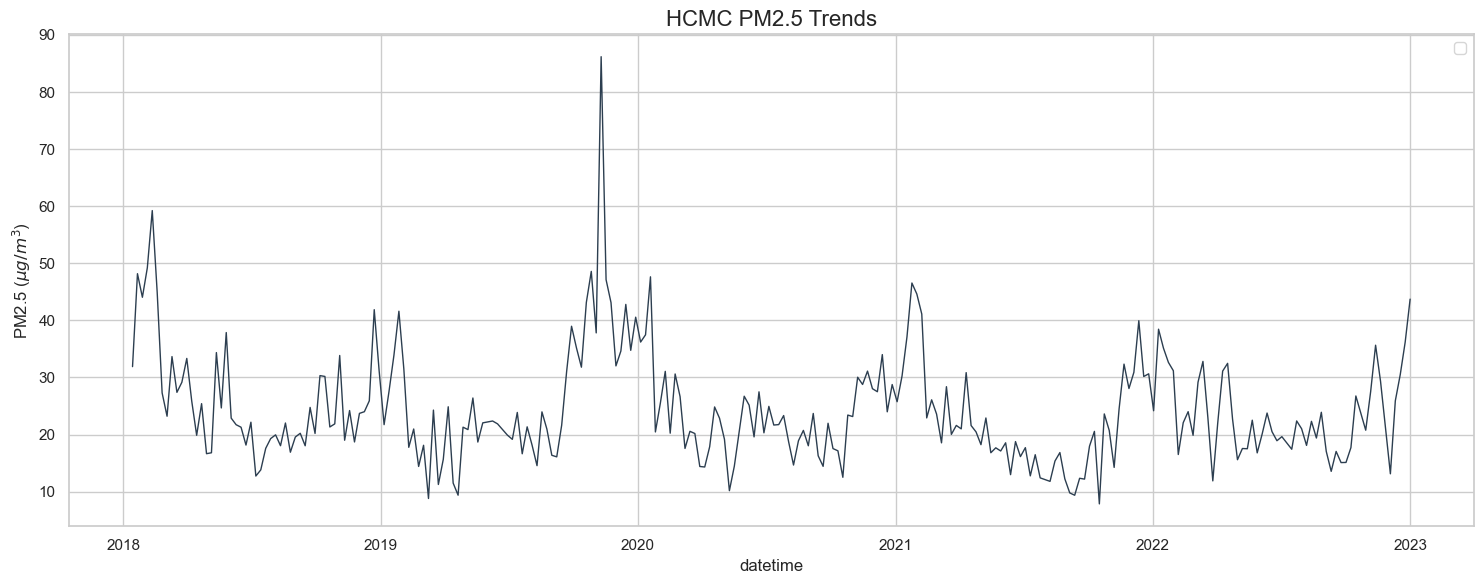

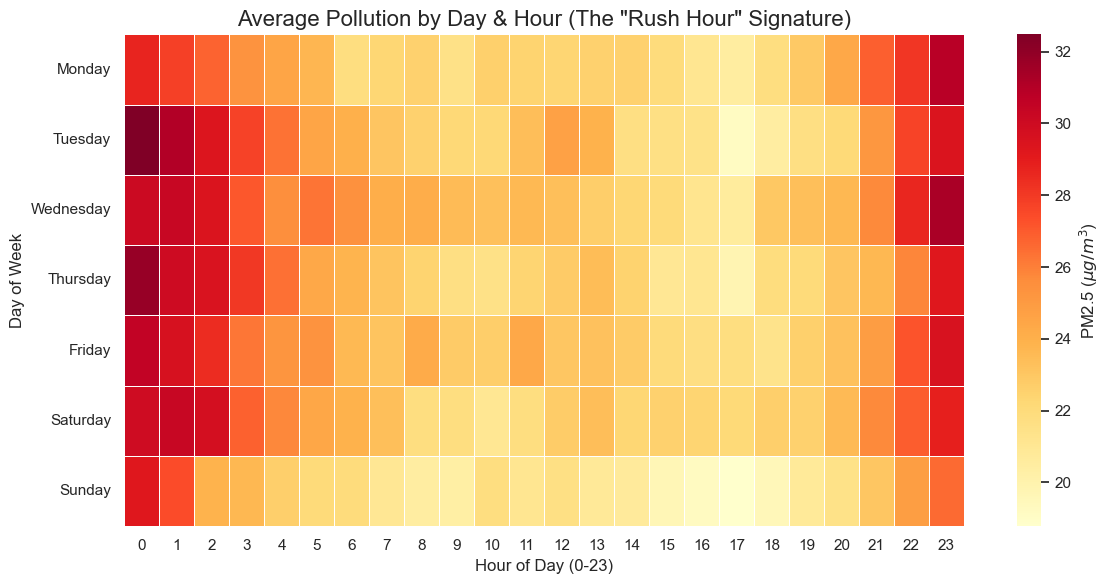

C:\Users\Admin\AppData\Local\Temp\ipykernel_24948\640532788.py:51: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='month', y='value', palette="coolwarm", showfliers=False)


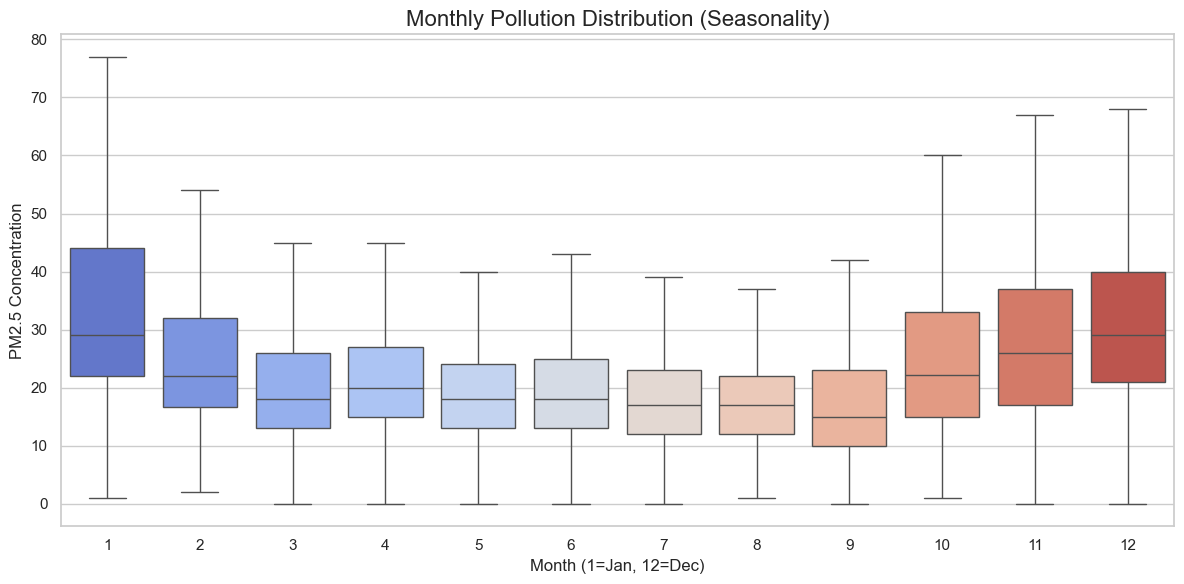

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


def plot(input_file):

    df = pd.read_csv(input_file)
    df['datetime'] = pd.to_datetime(df['datetime'])
    
    # Convert UTC to HCMC local time (ICT = UTC+7)
    df['datetime'] = df['datetime'].dt.tz_localize('UTC').dt.tz_convert('Asia/Ho_Chi_Minh')

    df['year'] = df['datetime'].dt.year
    df['month'] = df['datetime'].dt.month
    df['hour'] = df['datetime'].dt.hour
    df['day_name'] = df['datetime'].dt.day_name()

    # Set the visual style
    sns.set_theme(style="whitegrid")

    # --- PLOT 1: THE 5-YEAR TIMELINE (The Big Picture) ---
    plt.figure(figsize=(15, 6))
    # Resample to Daily or Week or Month to make the plot readable (too much noise in hourly)
    daily_df = df.set_index('datetime').resample('W')['value'].mean().reset_index()

    sns.lineplot(data=daily_df, x='datetime', y='value', color='#2c3e50', linewidth=1)


    plt.title('HCMC PM2.5 Trends', fontsize=16)
    plt.ylabel('PM2.5 ($μg/m^3$)')
    plt.legend()
    plt.tight_layout()
    plt.show()

    # --- PLOT 2: "RUSH HOUR" HEATMAP---
    # We pivot the data: Rows = Day of Week, Columns = Hour of Day
    pivot_table = df.pivot_table(index='day_name', columns='hour', values='value', aggfunc='mean')

    # Reorder days to start on Monday
    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    pivot_table = pivot_table.reindex(days_order)

    plt.figure(figsize=(12, 6))
    sns.heatmap(pivot_table, cmap="YlOrRd", linewidths=0.5, cbar_kws={'label': 'PM2.5 ($μg/m^3$)'})
    plt.title('Average Pollution by Day & Hour (The "Rush Hour" Signature)', fontsize=16)
    plt.xlabel('Hour of Day (0-23)')
    plt.ylabel('Day of Week')
    plt.tight_layout()
    plt.show()

    # --- PLOT 3: SEASONAL BOXPLOT (Rainy vs Dry Season) ---
    plt.figure(figsize=(12, 6))
    sns.boxplot(data=df, x='month', y='value', palette="coolwarm", showfliers=False)
    plt.title('Monthly Pollution Distribution (Seasonality)', fontsize=16)
    plt.xlabel('Month (1=Jan, 12=Dec)')
    plt.ylabel('PM2.5 Concentration')
    plt.tight_layout()
    plt.show()

plot(input_file)

# CMT8 Sensor

In [10]:
input_file = "data/hcmc_cmt8_cleaned_data_2.csv"
df = pd.read_csv(input_file)
df.head()

,datetime,value,lag_1h,lag_2h,lag_3h,lag_24h,lag_168h,roll_mean_24h,roll_std_24h,hour_sin,hour_cos,day_sin,day_cos,month_sin,month_cos
0,2024-11-26 17:00:00,27.700500,25.930167,24.704167,23.085791,38.094333,29.139999,37.549868,8.488061,-0.965926,-2.588190e-01,0.781831,0.62349,-0.5,0.866025
1,2024-11-26 18:00:00,38.698333,27.700500,25.930167,24.704167,44.554292,29.150000,37.305870,8.361177,-1.000000,-1.836970e-16,0.781831,0.62349,-0.5,0.866025
2,2024-11-26 19:00:00,42.786583,38.698333,27.700500,25.930167,40.269292,31.783333,37.410757,8.415580,-0.965926,2.588190e-01,0.781831,0.62349,-0.5,0.866025
3,2024-11-26 20:00:00,48.428459,42.786583,38.698333,27.700500,36.862958,30.950000,37.892653,8.708871,-0.866025,5.000000e-01,0.781831,0.62349,-0.5,0.866025
4,2024-11-26 21:00:00,47.183084,48.428459,42.786583,38.698333,34.507750,30.216667,38.420792,8.877382,-0.707107,7.071068e-01,0.781831,0.62349,-0.5,0.866025


In [15]:
df.isnull().sum()

datetime         0
value            0
lag_1h           0
lag_2h           0
lag_3h           0
lag_24h          0
lag_168h         0
roll_mean_24h    0
roll_std_24h     0
hour_sin         0
hour_cos         0
day_sin          0
day_cos          0
month_sin        0
month_cos        0
dtype: int64

In [11]:
df.isna().sum()

datetime         0
value            0
lag_1h           0
lag_2h           0
lag_3h           0
lag_24h          0
lag_168h         0
roll_mean_24h    0
roll_std_24h     0
hour_sin         0
hour_cos         0
day_sin          0
day_cos          0
month_sin        0
month_cos        0
dtype: int64

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8826 entries, 0 to 8825
Data columns (total 15 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   datetime       8826 non-null   object 
 1   value          8826 non-null   float64
 2   lag_1h         8826 non-null   float64
 3   lag_2h         8826 non-null   float64
 4   lag_3h         8826 non-null   float64
 5   lag_24h        8826 non-null   float64
 6   lag_168h       8826 non-null   float64
 7   roll_mean_24h  8826 non-null   float64
 8   roll_std_24h   8826 non-null   float64
 9   hour_sin       8826 non-null   float64
 10  hour_cos       8826 non-null   float64
 11  day_sin        8826 non-null   float64
 12  day_cos        8826 non-null   float64
 13  month_sin      8826 non-null   float64
 14  month_cos      8826 non-null   float64
dtypes: float64(14), object(1)
memory usage: 1.0+ MB


C:\Users\Admin\AppData\Local\Temp\ipykernel_21120\3680185822.py:30: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


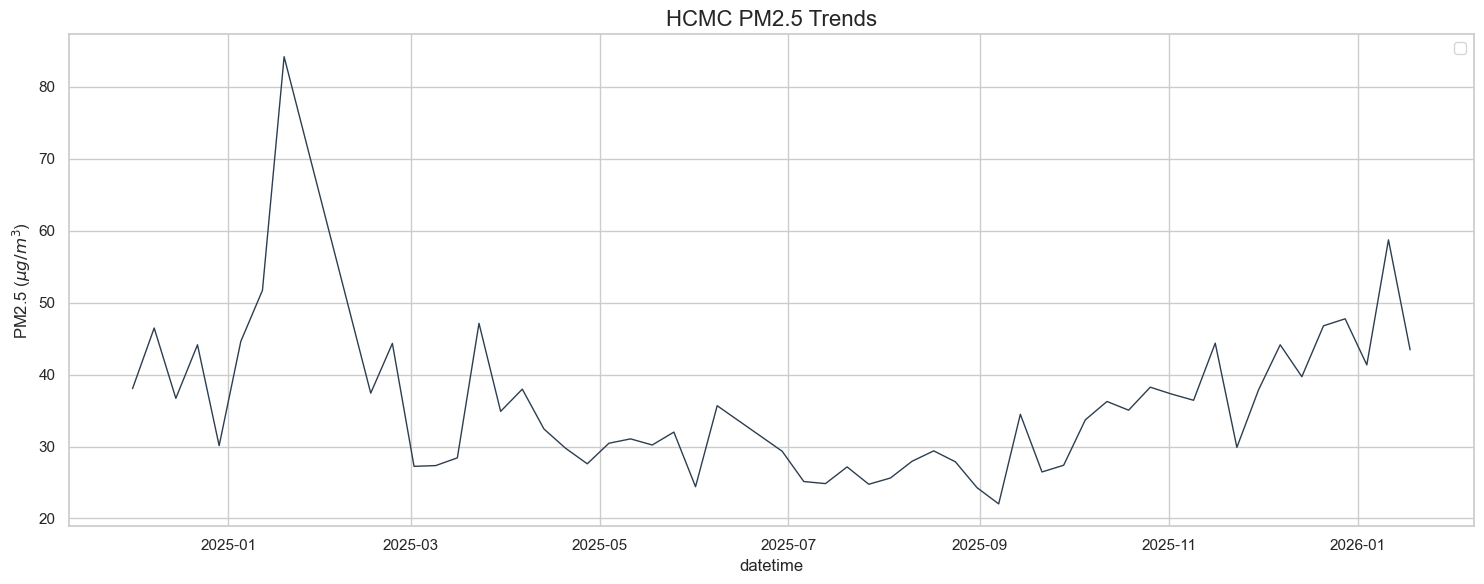

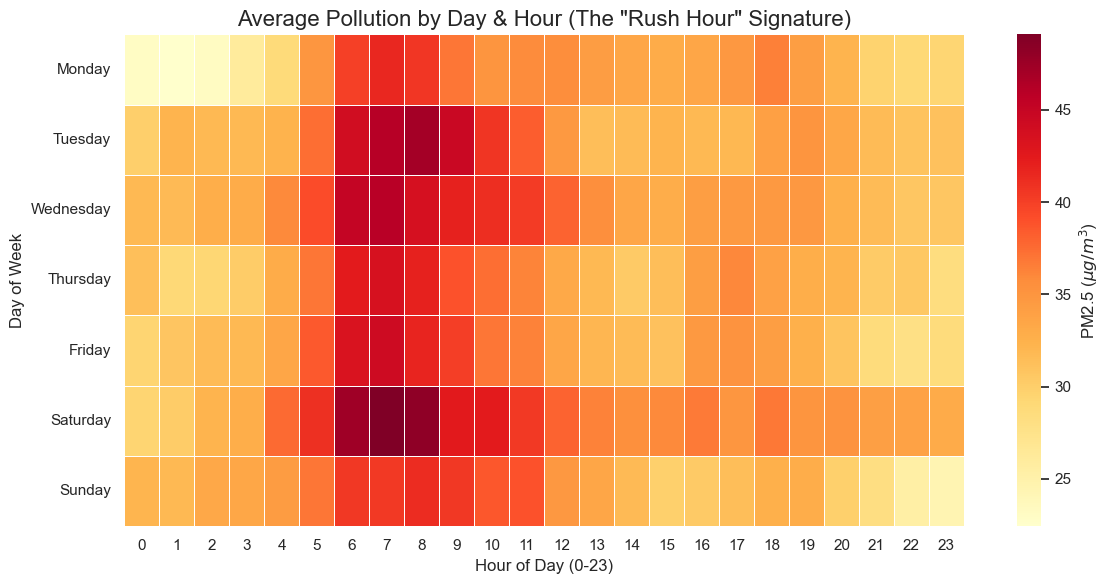

C:\Users\Admin\AppData\Local\Temp\ipykernel_21120\3680185822.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='month', y='value', palette="coolwarm", showfliers=False)


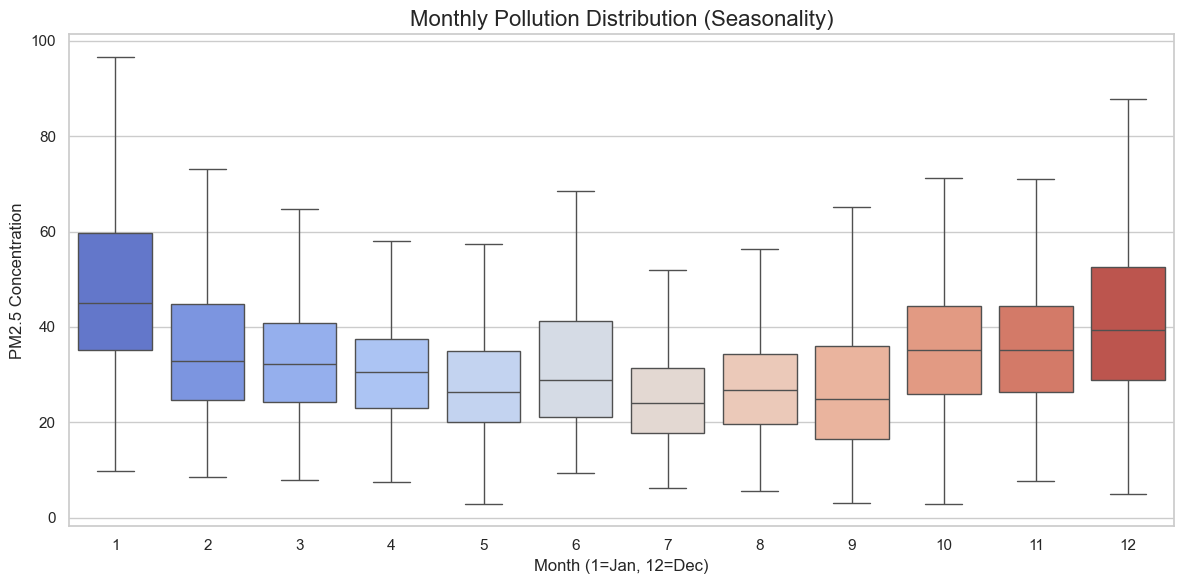

In [16]:
plot(input_file)